In [19]:
# 데이터 및 필요 패키지 import 

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# 윈도우 - 맑은 고딕
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 1. 데이터 로드 (구분자가 세미콜론(;)임에 유의)
df = pd.read_csv('marketing_campaign.csv', sep=';')

print('행/열 개수:', df.shape)
df.head()

행/열 개수: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
# 1. 결측치 확인
print("1. 결측치 확인")
df.info()
print()
print('결측치 개수:')
print(df.isnull().sum()[df.isnull().sum() > 0])

print()
print("2. Education 컬럼 값 분포 확인")

# 2. Education 컬럼 값 분포 확인
print(df['Education'].value_counts())
print()

# 3. Marital_Status 정제
print("3. 결혼여부")
print(df['Marital_Status'].value_counts())
print()

# 4. 캠페인별 수락(1) / 미수락(0) 인원 수
cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
print("3. 캠페인별 수락/미수락 인원 수")

for col in cols:
    counts = df[col].value_counts().sort_index()
    n0 = counts.get(0, 0)
    n1 = counts.get(1, 0)
    print(f'{col}: 0={n0}, 1={n1} (수락률 {n1/len(df)*100:.1f}%)')

print()
# 5. Dt_Customer를 날짜(date) 포맷으로 변환
print("4. Dt_Customer 날짜 포맷 변환")
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%Y-%m-%d')

print('변환 후 dtype:', df['Dt_Customer'].dtype)
print(df['Dt_Customer'].head())

# 4. 고객별 캠페인 수락 개수 분포 (0~5개)

print()
print("4. 고객별 캠페인 수락 개수 분포 (0-5)")
df['num_accepted'] = df[cols].sum(axis=1)

counts = df['num_accepted'].value_counts().sort_index()
total = len(df)

for n, c in counts.items():
    print(f'{n}개 수락: {c}명 ({c/total*100:.2f}%)')

print()
print('총합:', counts.sum(), '/', total)

cols_no_id = [c for c in df.columns if c != 'ID']
cols_no_id_response = [c for c in df.columns if c not in ['ID', 'Response']]

# ── 유형 1: ID만 다르고 나머지 모든 칼럼(Response 포함) 동일 ──
type1_mask = df.duplicated(subset=cols_no_id, keep=False)
type1_rows = df[type1_mask].sort_values(cols_no_id)

print('[유형 1] ID만 다르고 나머지 전부 동일')
print('연루 행 개수:', len(type1_rows), '/ 제거 대상:', df.duplicated(subset=cols_no_id, keep='first').sum())
print()

# ── 유형 2: ID, Response만 다르고 나머지 칼럼 동일 (즉, Response 자체는 다른 경우만) ──
type2_mask_all = df.duplicated(subset=cols_no_id_response, keep=False)
type2_candidates = df[type2_mask_all]

# 그룹별로 Response 값이 실제로 2가지 이상 섞여 있는 그룹만 필터링
resp_nunique = type2_candidates.groupby(cols_no_id_response)['Response'].transform('nunique')
type2_rows = type2_candidates[resp_nunique > 1].sort_values(cols_no_id_response)

print('[유형 2] ID와 Response만 다르고 나머지 전부 동일 (Response 값 자체가 다른 경우)')
print('연루 행 개수:', len(type2_rows))
print()

print('=== 유형 1 상세 ===')
print(type1_rows)

print('=== 유형 2 상세 ===')
print(type2_rows)



1. 결측치 확인
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   str           
 3   Marital_Status       2240 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[us]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-null

In [ ]:
# 데이터 전처리를 위한 사본 생성
import shutil

# 원본 CSV 파일의 사본 생성 (전처리는 사본에서 진행)
src_path = 'marketing_campaign.csv'
dst_path = 'marketing_campaign_preprocessed.csv'

shutil.copy(src_path, dst_path)

print(f'사본 생성 완료: {dst_path}')

사본 생성 완료: marketing_campaign_preprocessed.csv


In [ ]:
# 사본을 불러와서 전처리 시작
df = pd.read_csv('marketing_campaign_preprocessed.csv', sep=';')

# 1. Year_Birth 이상치(1893, 1899, 1900) 3개 행 삭제
before = len(df)

df = df[~df['Year_Birth'].isin([1893, 1899, 1900])].reset_index(drop=True)

after = len(df)
print(f'삭제 전 행 개수: {before}')
print(f'삭제 후 행 개수: {after}')
print(f'삭제된 행 개수: {before - after}')

# 확인: Year_Birth 최솟값 재확인
print(df['Year_Birth'].min())
df['Year_Birth'].nsmallest(5)

삭제 전 행 개수: 2240
삭제 후 행 개수: 2237
삭제된 행 개수: 3
1940


1947    1940
421     1941
39      1943
355     1943
412     1943
Name: Year_Birth, dtype: int64

In [39]:
# 2. Dt_Customer 열의 현재 형식(dtype) 확인 & 변환
print('현재 dtype:', df['Dt_Customer'].dtype)
print(df['Dt_Customer'].head())

# datetime 형식이 아니면 변환
if not pd.api.types.is_datetime64_any_dtype(df['Dt_Customer']):
    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%Y-%m-%d')
    print('datetime으로 변환 완료')
else:
    print('이미 datetime 형식임')

print()
print('변환 후 dtype:', df['Dt_Customer'].dtype)
df['Dt_Customer'].head()

현재 dtype: datetime64[us]
0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[us]
이미 datetime 형식임

변환 후 dtype: datetime64[us]


0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[us]

In [40]:
# 3. Education 컬럼에서 '2n Cycle'을 'Master'로 병합
print('병합 전:')
print(df['Education'].value_counts())

df['Education'] = df['Education'].replace('2n Cycle', 'Master')

print()
print('병합 후:')
print(df['Education'].value_counts())

병합 전:
Education
Graduation    1127
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

병합 후:
Education
Graduation    1127
Master         571
PhD            485
Basic           54
Name: count, dtype: int64


In [41]:
# 4. Marital_Status에서 'Absurd', 'Alone', 'YOLO'를 'Single'로 통합
print('통합 전:')
print(df['Marital_Status'].value_counts())

df['Marital_Status'] = df['Marital_Status'].replace(
    ['Absurd', 'Alone', 'YOLO'], 'Single'
)

print()
print('통합 후:')
print(df['Marital_Status'].value_counts())

통합 전:
Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

통합 후:
Marital_Status
Married     864
Together    579
Single      486
Divorced    231
Widow        77
Name: count, dtype: int64


In [44]:
# 5. Income 열 정제

# Income 결측치를 중앙값으로 대체
median_income = df['Income'].median()
print(f'Income 중앙값: {median_income}')

missing_before = df['Income'].isnull().sum()
df['Income'] = df['Income'].fillna(median_income)
print(f'결측치 {missing_before}건 → 중앙값({median_income})으로 대체 완료')
print('남은 결측치:', df['Income'].isnull().sum())
print()
# ID 9432의 이상치(666666)를 중앙값으로 대체
print('대체 전:')
print(df[df['ID']==9432][['ID','Income']])

df.loc[df['ID']==9432, 'Income'] = median_income

print()
print('대체 후:')
print(df[df['ID']==9432][['ID','Income']])
print()

# 최종 확인
print('결측치 개수:', df['Income'].isnull().sum())
print()
print(df['Income'].describe())

Income 중앙값: 51373.0
결측치 0건 → 중앙값(51373.0)으로 대체 완료
남은 결측치: 0

대체 전:
        ID   Income
2230  9432  51373.0

대체 후:
        ID   Income
2230  9432  51373.0

결측치 개수: 0

count      2237.000000
mean      51952.263746
std       21406.684379
min        1730.000000
25%       35523.000000
50%       51373.000000
75%       68274.000000
max      162397.000000
Name: Income, dtype: float64


In [47]:
# 6. Kidhome + Teenhome을 합쳐서 Children 컬럼 생성
df['Children'] = df['Kidhome'] + df['Teenhome']

# Kidhome, Teenhome 바로 다음 위치에 배치
cols = list(df.columns)
cols.remove('Children')
teenhome_idx = cols.index('Teenhome')
cols.insert(teenhome_idx + 1, 'Children')
df = df[cols]

print(df[['Kidhome', 'Teenhome', 'Children']].head(10))
# 확인
print(df['Children'].value_counts().sort_index())

   Kidhome  Teenhome  Children
0        0         0         0
1        1         1         2
2        0         0         0
3        1         0         1
4        1         0         1
5        0         1         1
6        0         1         1
7        1         0         1
8        1         0         1
9        1         1         2
Children
0     637
1    1126
2     421
3      53
Name: count, dtype: int64


In [ ]:
# 7. Z_CostContact, Z_Revenue 컬럼 삭제 (원본에는 보존, 전처리본에서만 제거)
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

print('삭제 후 컬럼 목록:')
print(df.columns.tolist())

삭제 후 컬럼 목록:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Children', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


In [ ]:
# 8. AcceptedCmp1~5 컬럼을 오름차순(1,2,3,4,5)으로 재정렬
# (값은 그대로 각 컬럼에 속한 채로 컬럼 위치만 이동)

cols = list(df.columns)

# 기존 AcceptedCmp 컬럼들의 위치(가장 먼저 나오는 인덱스)를 찾음
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
first_idx = min(cols.index(c) for c in cmp_cols)

# 기존 위치에서 AcceptedCmp 컬럼들을 제거한 뒤, 오름차순으로 다시 삽입
cols_without_cmp = [c for c in cols if c not in cmp_cols]
new_cols = cols_without_cmp[:first_idx] + cmp_cols + cols_without_cmp[first_idx:]

df = df[new_cols]

print(df.columns.tolist())

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Children', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain', 'Response']


In [ ]:
# 9. ID를 제외한 나머지 모든 컬럼 기준으로 완전 중복된 행 확인 후, 첫 번째만 남기고 삭제
cols_no_id = [c for c in df.columns if c != 'ID']

before = len(df)
dup_count = df.duplicated(subset=cols_no_id, keep='first').sum()
print(f'삭제 대상 중복 행 개수: {dup_count}')

df = df.drop_duplicates(subset=cols_no_id, keep='first').reset_index(drop=True)

after = len(df)
print(f'삭제 전 행 개수: {before}')
print(f'삭제 후 행 개수: {after}')
print(f'삭제된 행 개수: {before - after}')

삭제 대상 중복 행 개수: 184
삭제 전 행 개수: 2237
삭제 후 행 개수: 2053
삭제된 행 개수: 184


In [ ]:
# 10. ID와 Response만 다르고 나머지 컬럼이 모두 동일한 행들을 찾아서,
# 그룹 내 Response 값이 실제로 섞여 있는 경우 Response=1인 행만 남김

cols_no_id_response = [c for c in df.columns if c not in ['ID', 'Response']]

# 중복 후보군 (ID, Response 제외 완전 동일)
dup_mask = df.duplicated(subset=cols_no_id_response, keep=False)
candidates = df[dup_mask]

# 그룹 내 Response 값이 2가지 이상 섞여 있는 그룹만 필터링 (진짜 대상)
resp_nunique = candidates.groupby(cols_no_id_response)['Response'].transform('nunique')
target_rows = candidates[resp_nunique > 1]

print('대상 그룹에 속한 행 개수:', len(target_rows))

# 삭제 대상: 이 그룹들 중 Response == 0인 행
to_drop = target_rows[target_rows['Response'] == 0]
print('삭제할 행 개수 (Response=0):', len(to_drop))

before = len(df)
df = df.drop(index=to_drop.index).reset_index(drop=True)
after = len(df)

print(f'삭제 전 행 개수: {before}')
print(f'삭제 후 행 개수: {after}')
print(f'삭제된 행 개수: {before - after}')

대상 그룹에 속한 행 개수: 38
삭제할 행 개수 (Response=0): 19
삭제 전 행 개수: 2053
삭제 후 행 개수: 2034
삭제된 행 개수: 19


In [ ]:
# 11. AcceptedCmp1~5 중 하나라도 1이면 1, 모두 0이면 0을 갖는 AnyAccepted 컬럼 생성 (맨 마지막에 추가)
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']

df['AnyAccepted'] = (df[cmp_cols].sum(axis=1) > 0).astype(int)

print(df.columns.tolist())
print()
print(df['AnyAccepted'].value_counts())

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Children', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain', 'Response', 'AnyAccepted']

AnyAccepted
0    1611
1     423
Name: count, dtype: int64


In [54]:
# 12. 전처리된 최종 결과물을 CSV 파일로 저장
output_path = 'marketing_campaign_preprocessed.csv'

df.to_csv(output_path, sep=';', index=False)

print(f'저장 완료: {output_path}')
print(f'최종 행/열 개수: {df.shape}')

저장 완료: marketing_campaign_preprocessed.csv
최종 행/열 개수: (2034, 29)


사용할 특징: ['Income', 'Age', 'Children', 'Education_encoded', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
결측치 확인:
Income               0
Age                  0
Children             0
Education_encoded    0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
dtype: int64
스케일링 후 shape: (2034, 10)


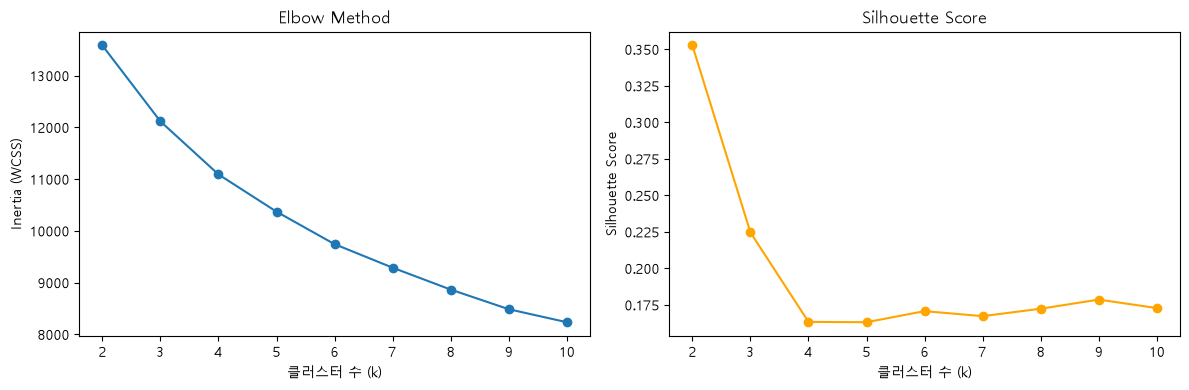

k=2: silhouette=0.3526
k=3: silhouette=0.2246
k=4: silhouette=0.1633
k=5: silhouette=0.1631
k=6: silhouette=0.1707
k=7: silhouette=0.1673
k=8: silhouette=0.1724
k=9: silhouette=0.1786
k=10: silhouette=0.1728


In [3]:
# 클러스터링
import pandas as pd

# 전처리된 CSV 파일 불러오기
df = pd.read_csv('marketing_campaign_preprocessed.csv', sep=';')

# Age 파생 (기준연도: 데이터 수집 마지막 연도인 2014년 기준)
df['Age'] = 2014 - df['Year_Birth']

# Education 순서형 인코딩 (Basic < Graduation < Master < PhD)
education_order = {'Basic': 0, 'Graduation': 1, 'Master': 2, 'PhD': 3}
df['Education_encoded'] = df['Education'].map(education_order)

df[['Age', 'Education', 'Education_encoded']].head()

# 클러스터링에 사용할 특징 컬럼 정의
demo_cols = ['Income', 'Age', 'Children', 'Education_encoded']
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

feature_cols = demo_cols + spend_cols
X = df[feature_cols].copy()

print('사용할 특징:', feature_cols)
print('결측치 확인:')
print(X.isnull().sum())

# 스케일링 (StandardScaler) - K-Means는 거리 기반이라 스케일 통일 필수
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('스케일링 후 shape:', X_scaled.shape)

# 적정 클러스터 수(k) 탐색: Elbow Method + Silhouette Score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=777, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_xlabel('클러스터 수 (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('클러스터 수 (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f'k={k}: silhouette={s:.4f}')

클러스터별 인원 수:
Cluster
0    635
1    593
2    330
3    476
Name: count, dtype: int64
K=4 실루엣 스코어: 0.1633


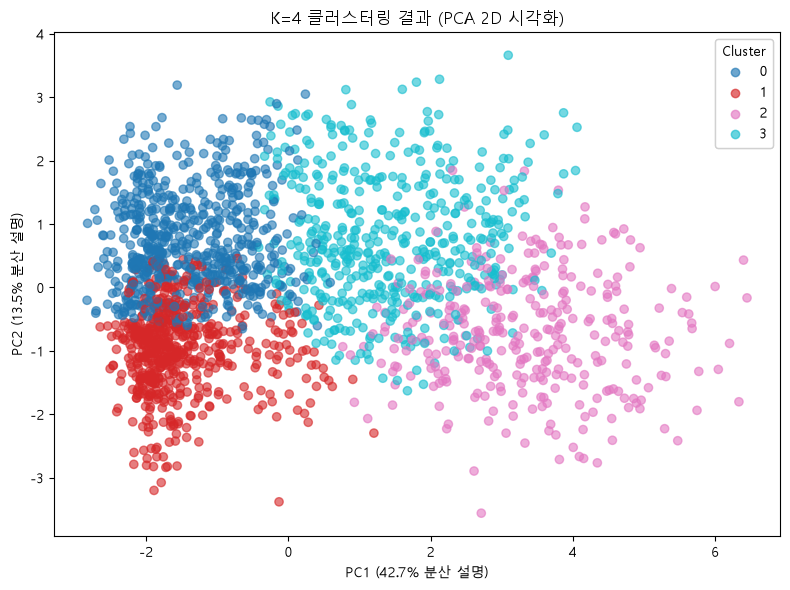

PC1+PC2 누적 설명 분산: 56.2%


In [8]:
# K=4로 K-Means 클러스터링 진행
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=777, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('클러스터별 인원 수:')
print(df['Cluster'].value_counts().sort_index())

# 클러스터별 실루엣 스코어 확인 (참고용)
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, df['Cluster'])
print(f'K=4 실루엣 스코어: {sil_score:.4f}')

# 클러스터별 특징 평균값 비교 (해석용)
cluster_summary = df.groupby('Cluster')[feature_cols].mean().round(1)
cluster_summary['count'] = df['Cluster'].value_counts().sort_index()
cluster_summary

# 지출 총액(TotalSpend) 및 주요 인구통계 함께 비교
df['TotalSpend'] = df[spend_cols].sum(axis=1)

cluster_profile = df.groupby('Cluster').agg(
    count=('ID', 'count'),
    avg_income=('Income', 'mean'),
    avg_age=('Age', 'mean'),
    avg_children=('Children', 'mean'),
    avg_total_spend=('TotalSpend', 'mean'),
    avg_response_rate=('Response', 'mean'),
    avg_any_accepted_rate=('AnyAccepted', 'mean')
).round(2)

cluster_profile

# PCA로 2차원 축소해서 클러스터 분포 시각화
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='tab10', alpha=0.6)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% 분산 설명)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% 분산 설명)')
ax.set_title('K=4 클러스터링 결과 (PCA 2D 시각화)')
legend1 = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

print(f'PC1+PC2 누적 설명 분산: {sum(pca.explained_variance_ratio_)*100:.1f}%')